In [1]:
import pandas as pd
import re
import unicodedata
import joblib
import nltk

from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report

### Cargamos los datos 

In [2]:
splits = {
    'train': 'data/train-00000-of-00001.parquet',
    'validation': 'data/validation-00000-of-00001.parquet',
    'test': 'data/test-00000-of-00001.parquet'
}

df = pd.read_parquet("hf://datasets/KRadim/edit_amazon_reviews_multi_es/" + splits["train"])
df.head()

,id,stars,review_body,review_title,language,product_category,lenght_review_body,lenght_review_title,lenght_product_category
0,111516,1,No llegaron las hélices,Mal servicio,es,electronics,23,12,11
1,107084,4,Me encanta lo ligera y manejable que es. Plega...,Manejable y ligera,es,baby_product,420,18,12
2,199386,1,"De las dos baterias , hay una que no funciona",No comprare mas,es,home_improvement,45,15,16
3,69470,2,"la iluminación es genial, pero el adhesivo pos...",el adhesivo no pega bien,es,home,105,24,4
4,114836,4,La he comprado porque por estética y colores e...,Original,es,home,165,8,4


### Eliminamos filas vacias 

In [3]:
df = df.dropna()
df.head()

,id,stars,review_body,review_title,language,product_category,lenght_review_body,lenght_review_title,lenght_product_category
0,111516,1,No llegaron las hélices,Mal servicio,es,electronics,23,12,11
1,107084,4,Me encanta lo ligera y manejable que es. Plega...,Manejable y ligera,es,baby_product,420,18,12
2,199386,1,"De las dos baterias , hay una que no funciona",No comprare mas,es,home_improvement,45,15,16
3,69470,2,"la iluminación es genial, pero el adhesivo pos...",el adhesivo no pega bien,es,home,105,24,4
4,114836,4,La he comprado porque por estética y colores e...,Original,es,home,165,8,4


### Mapping de las clasificaciones segun su stars

In [4]:
map_calificacion = {
    1: "Muy malo",
    2: "Malo",
    3: "Regular",
    4: "Bueno",
    5: "Excelente"
}

df["stars"] = df["stars"].map(map_calificacion)
df.head()

,id,stars,review_body,review_title,language,product_category,lenght_review_body,lenght_review_title,lenght_product_category
0,111516,Muy malo,No llegaron las hélices,Mal servicio,es,electronics,23,12,11
1,107084,Bueno,Me encanta lo ligera y manejable que es. Plega...,Manejable y ligera,es,baby_product,420,18,12
2,199386,Muy malo,"De las dos baterias , hay una que no funciona",No comprare mas,es,home_improvement,45,15,16
3,69470,Malo,"la iluminación es genial, pero el adhesivo pos...",el adhesivo no pega bien,es,home,105,24,4
4,114836,Bueno,La he comprado porque por estética y colores e...,Original,es,home,165,8,4


### stopwords y func para hacer limpieza de texto review_title

In [5]:
stop_words = set(stopwords.words('spanish'))

def limpiar_texto(texto):
    texto = texto.lower()
    texto = re.sub(r"[^a-zA-Zñáéíóúü\s]", "", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto

In [6]:
df["review_title"] = df["review_title"].apply(limpiar_texto)
df.head()

,id,stars,review_body,review_title,language,product_category,lenght_review_body,lenght_review_title,lenght_product_category
0,111516,Muy malo,No llegaron las hélices,mal servicio,es,electronics,23,12,11
1,107084,Bueno,Me encanta lo ligera y manejable que es. Plega...,manejable y ligera,es,baby_product,420,18,12
2,199386,Muy malo,"De las dos baterias , hay una que no funciona",no comprare mas,es,home_improvement,45,15,16
3,69470,Malo,"la iluminación es genial, pero el adhesivo pos...",el adhesivo no pega bien,es,home,105,24,4
4,114836,Bueno,La he comprado porque por estética y colores e...,original,es,home,165,8,4


### Definimos nuestra variable X e Y

In [7]:
x = df["review_title"]
y = df["stars"]

### Entrenamiento del modelo

In [8]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

### Se utilizó el modelo LinearSVC debido a su alto rendimiento en tareas de clasificación de texto, especialmente cuando se trabaja con representaciones vectoriales como TF-IDF.

In [9]:
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1,2),
        max_features=15000,
        min_df=2
    )),
    ("modelo", LinearSVC(class_weight="balanced", C=1.0))
])

#Entrenar el modelo
pipeline.fit(X_train, y_train)

#Predecir y evaluar el modelo
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       Bueno       0.42      0.42      0.42      7987
   Excelente       0.54      0.57      0.55      7985
        Malo       0.42      0.38      0.40      7980
    Muy malo       0.58      0.64      0.61      7970
     Regular       0.38      0.36      0.37      7978

    accuracy                           0.47     39900
   macro avg       0.47      0.47      0.47     39900
weighted avg       0.47      0.47      0.47     39900



In [10]:
from sklearn.linear_model import LogisticRegression

pipeline_lr = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1,2),
        max_features=15000,
        min_df=2
    )),
    ("modelo", LogisticRegression(class_weight="balanced", C=1.0, max_iter=1000))
])

pipeline_lr.fit(X_train, y_train)

y_pred_lr = pipeline_lr.predict(X_test)
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

       Bueno       0.43      0.43      0.43      7987
   Excelente       0.55      0.57      0.56      7985
        Malo       0.43      0.40      0.41      7980
    Muy malo       0.59      0.64      0.61      7970
     Regular       0.38      0.37      0.37      7978

    accuracy                           0.48     39900
   macro avg       0.48      0.48      0.48     39900
weighted avg       0.48      0.48      0.48     39900



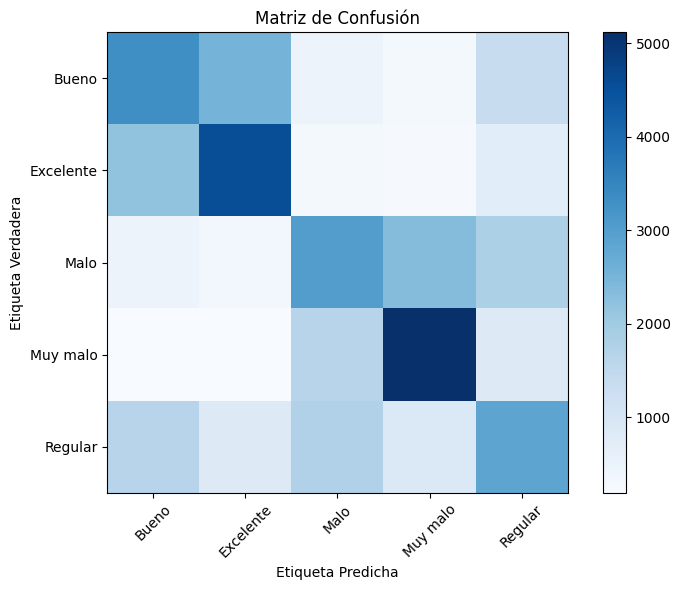

In [11]:
#Matriz de confusión
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels=pipeline.classes_)
plt.figure(figsize=(8,6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Matriz de Confusión")
plt.colorbar()
tick_marks = range(len(pipeline.classes_))
plt.xticks(tick_marks, pipeline.classes_, rotation=45)
plt.yticks(tick_marks, pipeline.classes_)
plt.ylabel("Etiqueta Verdadera")
plt.xlabel("Etiqueta Predicha")
plt.tight_layout()
plt.show()


In [ ]:
joblib.dump(pipeline, "pipeline_sentimientos.pkl")
modelo_cargado = joblib.load("pipeline_sentimientos.pkl")

texto_prueba = ["Excelente producto, superó mis expectativas!"]
pred = modelo_cargado.predict(texto_prueba)

print(pred[0])